# GMSH Displacement Animation Artifact

This notebook owns the durable docs-local GMSH animation artifact: a GMSH v4.1 mesh carrying time-stepped displacement `$NodeData`, plus a `.geo` companion that merges the static STEP and animated rotor mesh.

The mesh-generation and visualization fixtures now live beside this notebook in `docs/gmsh_animation/`. The notebook verifies the artifact structure and writes a durable JSON inspection record.

## Inspect the input meshes before reading displacement frames

What body is being animated? These saved WebGUI scenes reload the adjacent
`rotor.vol` and `stator.vol`, expose their element and label inventories, and
show their separate geometries. Radia MCP's GMSH workflow owns animation
and post-processing instructions; `radia-cubit` owns export guidance.

These are the existing reference meshes, **not a new Cubit export**. The
structural/quality `check-vol` gate runs before display and the reports are
saved. A missing CAD sidecar or application-specific label contract is not
silently replaced by an invented one. Each view is independently centered:
they are not a registered rotor/stator assembly or an animation. The GMSH
artifact below remains the time-dependent displacement evidence. No magnetic
field or structural-dynamics solution is implied by these mesh views.


In [1]:
from pathlib import Path
import hashlib, json, math, platform, socket, sys
from datetime import datetime, timezone
from importlib.metadata import version
import ngsolve as ng
from ngsolve.webgui import Draw
ng.SetNumThreads(2)
from collections import Counter
from cubit_mesh_export.check import check_consistency
meshes={}
rows=[]
for name in ['rotor','stator']:
    path=Path(name+'.vol')
    report=check_consistency(str(path))
    assert report['passed'], report
    mesh=ng.Mesh(str(path))
    meshes[name]=mesh
    rows.append(dict(name=name,sha256=hashlib.sha256(path.read_bytes()).hexdigest(),
                     elements=dict(Counter(str(e.type) for e in mesh.Elements(ng.VOL))),
                     materials=list(mesh.GetMaterials()),boundaries=list(mesh.GetBoundaries()),
                     check_vol=report))
metrics=dict(meshes=rows)
print(json.dumps(metrics,indent=2))


{
  "meshes": [
    {
      "name": "rotor",
      "sha256": "3dda7f5b6608763cf65c2484c191eef265d3fc37811d7ba58cd5cbfd6aaa95b6",
      "elements": {
        "ET.TET": 1003
      },
      "materials": [
        "rotor"
      ],
      "boundaries": [
        "rotor_surface",
        "rotor_surface",
        "rotor_surface"
      ],
      "check_vol": {
        "schema": "cubit-mesh-export.vol-check.v1",
        "generated_at_utc": "2026-09-14T20:22:07.018158+00:00",
        "versions": {
          "cubit_mesh_export": "0.14.15",
          "ngsolve": "6.2.2606",
          "python": "3.12.10"
        },
        "passed": true,
        "vol_file": "rotor.vol",
        "json_file": null,
        "threshold_pct": 1.0,
        "cad_reference": {
          "available": false,
          "file": null,
          "auto_discovered": false,
          "mesh_only_materials": [],
          "metadata_checks": {}
        },
        "mesh": {
          "dimension": 3,
          "curve_order": 2,
          

### Rotor input mesh

In [2]:
scene = Draw(meshes['rotor'], name='Rotor_input_mesh', order=3, draw_vol=True, draw_surf=True, width='100%', height='480px')
scene.GenerateHTML(filename='scene_0.html')


'\n<!DOCTYPE html>\n<html>\n    <head>\n        <title>NGSolve WebGUI</title>\n        <meta name=\'viewport\' content=\'width=device-width, user-scalable=no\'/>\n        <style>\n            body{\n                margin:0;\n                overflow:hidden;\n            }\n            canvas{\n                cursor:grab;\n                cursor:-webkit-grab;\n                cursor:-moz-grab;\n            }\n            canvas:active{\n                cursor:grabbing;\n                cursor:-webkit-grabbing;\n                cursor:-moz-grabbing;\n            }\n        </style>\n    </head>\n    <body>\n          <script src="https://cdn.jsdelivr.net/npm/webgui@0.2.39/dist/webgui.js"></script>\n          </script>\n          <script>\n            var render_data = {"gui_settings": {}, "ngsolve_version": "6.2.2606", "mesh_dim": 3, "order2d": 3, "order3d": 2, "draw_vol": null, "draw_surf": null, "objects": [], "deformation": false, "mesh_regions_2d": 3, "mesh_regions_3d": 1, "names":

### Stator reference mesh

In [3]:
scene = Draw(meshes['stator'], name='Stator_reference_mesh', order=3, draw_vol=True, draw_surf=True, width='100%', height='480px')
scene.GenerateHTML(filename='scene_1.html')


'\n<!DOCTYPE html>\n<html>\n    <head>\n        <title>NGSolve WebGUI</title>\n        <meta name=\'viewport\' content=\'width=device-width, user-scalable=no\'/>\n        <style>\n            body{\n                margin:0;\n                overflow:hidden;\n            }\n            canvas{\n                cursor:grab;\n                cursor:-webkit-grab;\n                cursor:-moz-grab;\n            }\n            canvas:active{\n                cursor:grabbing;\n                cursor:-webkit-grabbing;\n                cursor:-moz-grabbing;\n            }\n        </style>\n    </head>\n    <body>\n          <script src="https://cdn.jsdelivr.net/npm/webgui@0.2.39/dist/webgui.js"></script>\n          </script>\n          <script>\n            var render_data = {"gui_settings": {}, "ngsolve_version": "6.2.2606", "mesh_dim": 3, "order2d": 3, "order3d": 2, "draw_vol": null, "draw_surf": null, "objects": [], "deformation": false, "mesh_regions_2d": 4, "mesh_regions_3d": 1, "names":

In [4]:
evidence=dict(schema='radia.docs.webgui_supplement.v1',
    generated_at_utc=datetime.now(timezone.utc).isoformat(),host=socket.gethostname(),
    python_executable=sys.executable,python_version=platform.python_version(),
    versions={p:version(p) for p in ['ngsolve','netgen-mesher','anywidget','cubit-mesh-export']},
    metrics=metrics,threads=2)
Path('evidence.json').write_text(json.dumps(evidence,indent=2),encoding='utf-8')


13215

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'gmsh_animation_inspect.py').exists():
    NOTEBOOK_DIR = Path('docs/gmsh_animation').resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

from gmsh_animation_inspect import inspect_example, write_results_json, format_summary

result = inspect_example()
json_path = write_results_json(result, NOTEBOOK_DIR / 'gmsh_animation_results.json')
print(format_summary(result))
print(f'\nwrote {json_path.relative_to(NOTEBOOK_DIR)}')

mesh_format: 4.1 0 8
nodes: 2430
elements: 1003
NodeData frames: 21
geo merges: stator.step, rotor_animation.msh
final displacement: 0.15 m
checks: v4.1=True, vector=True, time_monotone=True, disp_monotone=True

wrote gmsh_animation_results.json


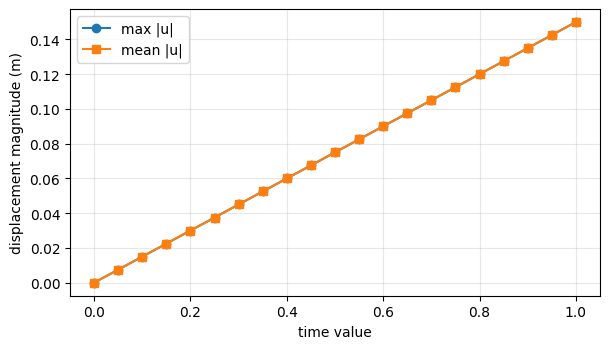

In [2]:
import matplotlib.pyplot as plt

frames = result['msh']['node_data']
times = [row['time_value'] for row in frames]
max_disp = [row['max_norm'] for row in frames]
mean_disp = [row['mean_norm'] for row in frames]

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(times, max_disp, marker='o', label='max |u|')
ax.plot(times, mean_disp, marker='s', label='mean |u|')
ax.set_xlabel('time value')
ax.set_ylabel('displacement magnitude (m)')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

The expected result is 21 vector `$NodeData` frames, monotonically increasing from zero to a 0.15 m displacement. The adjacent `gmsh_animation_results.json` stores the checked mesh headers, time values, displacement norms, and file references.

## Artifact meaning and evidence

Gmsh provides a mesh-based post-processing representation
[@geuzaine2009gmsh]. This notebook demonstrates time-indexed nodal displacement
data and a geometry/view composition; it does not run an electromagnetic or
mechanical dynamics solver. At time $t_n$, the displayed position is the
reference position plus the prescribed displacement, subject to the declared
visualization scale.

`gmsh_animation_inspect` checks node/time records and the companion files.
The saved summary establishes artifact structure, not physical correctness
of the prescribed motion. Frame rate is a presentation choice and must not be
confused with the physical time values in the data. A static CAD overlay is
not automatically deforming with the mesh. The Radia contribution is the
checked export/inspection contract; the Radia MCP Gmsh animation capability
owns the current operational recipe. No independent solver validation is
claimed by this operational example.


## References

Generated from the canonical bibliography: [gmsh_animation.bbl](gmsh_animation.bbl).

<h3 class='likesectionHead' id='references'><a id='x1-1000'></a>References</h3>
<!-- l. 2 --><p class='noindent'>
   </p><section class='thebibliography' role='doc-bibliography'><dl><dt>
 [1]</dt><dd><a id='Xgeuzaine2009gmsh'></a>C. Geuzaine and J.-F. Remacle, “Gmsh: A 3-d finite element mesh generator
   with built-in pre- and post-processing facilities,” <span class='ecti-1000'>International Journal for
   Numerical Methods in Engineering</span>, vol. 79, no. 11, pp. 1309–1331, 2009.
   [Online]. Available: <a class='url' href='https://orbi.uliege.be/handle/2268/22742'>https://orbi.uliege.be/handle/2268/22742</a>
   </dd></dl></section>
